In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Age: How old a person is. Older people may have more heart problems.

Sex: Whether the person is a boy (1) or a girl (0). Boys may have more heart problems.

cp (Chest Pain):
0: Normal heart pain.
1: Unusual heart pain.
2: Pain not because of the heart.
3: No pain at all.

trestbps (Resting Blood Pressure): The strength of the blood pushing against the veins when the person is resting. Higher is not good.

chol (Cholesterol): The amount of fat in the blood. Too much fat can block the heart.

fbs (Fasting Blood Sugar): Is the sugar in the blood too high after not eating? (1 = yes, 0 = no). Too much sugar is bad for the heart.

restecg (Heart Test):
0: Normal heart.
1: Some problem in the heart.
2: Big problem with the heart.

thalach (Max Heart Rate): The fastest the heart beats when running or exercising. A slower beat might mean trouble.

exang (Exercise Pain): Does the heart hurt when exercising? (1 = yes, 0 = no). Pain means the heart might be blocked.

oldpeak: How stressed the heart feels when working hard. Higher is not good.

slope (Heart Activity Shape):
0: Bad heart.
1: Okay heart.
2: Healthy heart.

ca (Blocked Blood Pipes): How many pipes (blood vessels) are blocked in the heart? (0–3). More blockages are bad.

thal (Heart Blood Issue):
1: Heart has permanent damage.
2: Normal heart.
3: Problem that can get better.

target: Does the person have a sick heart? (1 = yes, 0 = no).

In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.shape

(303, 14)

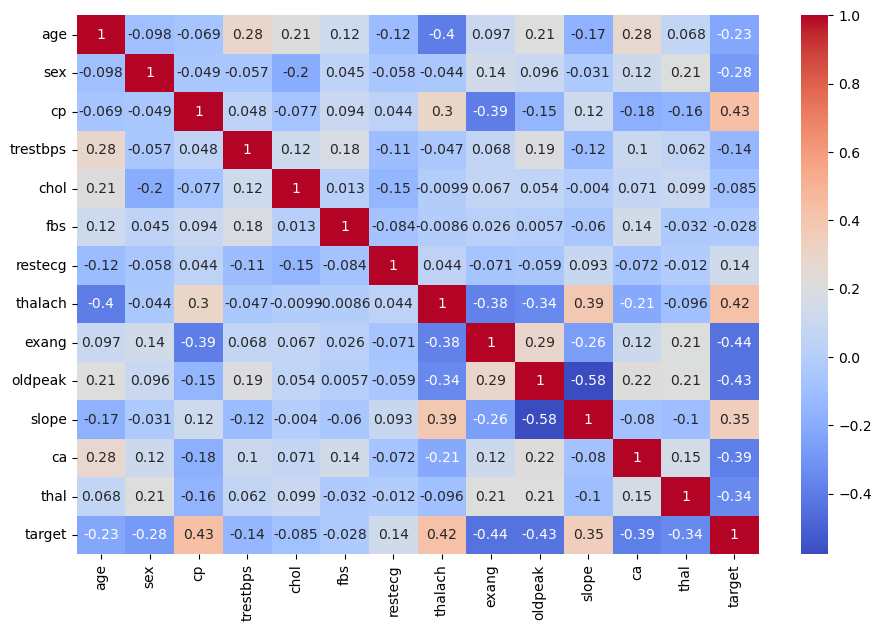

In [6]:
plt.figure(figsize=(11,7))
sns.heatmap(data = df.corr(),annot = True,cmap='coolwarm')
plt.show()

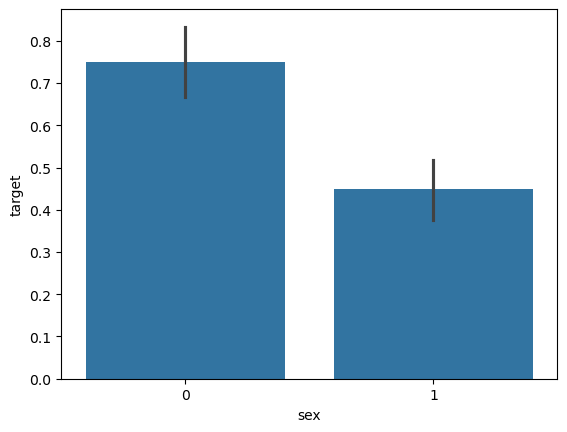

In [7]:
sns.barplot(data = df, x = 'sex',y='target')
plt.show()

We notice, that females are more likely to have heart problems than males

In [8]:
df['target'].unique()

array([1, 0], dtype=int64)

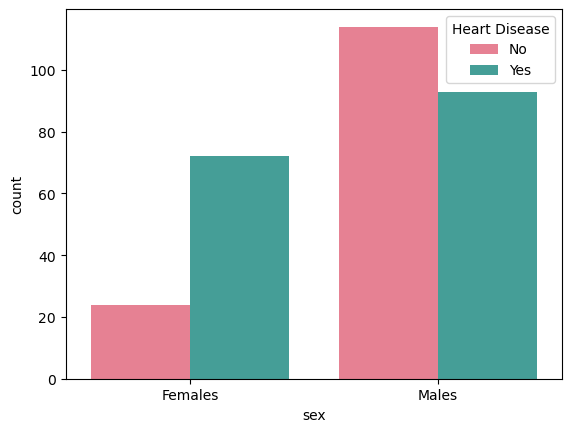

target
1    165
0    138
Name: count, dtype: int64


In [9]:
data = sns.countplot(data = df ,x = df['sex'],hue = 'target',palette='husl')
data.set_xticklabels(['Females','Males'])
data.legend(title = 'Heart Disease',labels = ['No','Yes'])
plt.show()

target_temp = df.target.value_counts()

print(target_temp)

In [10]:
print("Percentage of people with heart problems: "+ str(round(target_temp[1]*100/303,2)))
print("Percentage of people without heart problems: "+ str(round(target_temp[0]*100/303,2)))

Percentage of people with heart problems: 54.46
Percentage of people without heart problems: 45.54


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x = df.drop(columns = 'target')
y = df['target']

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x_train.shape

(242, 13)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [16]:
from sklearn.metrics import precision_score,accuracy_score,f1_score,recall_score

In [17]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators = 100,random_state=42),
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}
metrics = {
    "Model":[],
    "Accuracy" : [],
    "F1 Score": [],
    "Recall": [],
    "Precision":[],
}
for model_name, model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    metrics['Model'].append(model_name)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1 Score'].append(f1)

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

                 Model  Accuracy  F1 Score   Recall  Precision
0        Random Forest  0.836066  0.843750  0.84375   0.843750
1  Logistic Regression  0.885246  0.892308  0.90625   0.878788
2        Decision Tree  0.754098  0.736842  0.65625   0.840000
3          Naive Bayes  0.868852  0.870968  0.84375   0.900000


In [18]:
input_data = (63	,1,	3,	145,	233,	1,	0,	150,	0,	2.3,	0	,0,1)
model = LogisticRegression()
model.fit(x_train,y_train)
# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

[1]
The Person has Heart Disease


In [19]:
import pickle

In [20]:
filename = 'Heart_model.sav'
pickle.dump(model, open(filename,'wb'))

In [21]:
# Save the model again
with open(r'C:/Users/TTBSADMIN/HEALTHCARE/Diabetes_model.sav', 'wb') as file:
    pickle.dump(model, file)

# Load the model again
with open(r'C:/Users/TTBSADMIN/HEALTHCARE/Diabetes_model.sav', 'rb') as file:
    loaded_model = pickle.load(file)

print("Model saved and loaded successfully!")


Model saved and loaded successfully!


In [22]:
loaded_model = pickle.load(open('Heart_model.sav','rb'))

In [23]:
for column in x.columns:
  print(column)

age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak
slope
ca
thal


In [24]:
import sklearn
print(sklearn.__version__)


1.5.1
